# Differentiable Simulation for Parameter Estimation

In this tutorial, we learn how to estimate initial conditions of a 1D wave equation by combining a finite-difference time-domain (FDTD) solver with automatic differentiation.

## Environment Setup

First, install the python dependencies and initialize the environment. You can use any package you like for auto-diff (e.g., PyTorch, JAX, TensorFlow, etc.), but for this demo we will use [Taichi](https://www.taichi-lang.org/).

In [51]:
# Install and import dependencies
!pip install taichi -q
import taichi as ti
import numpy as np
import matplotlib.pyplot as plt

In [52]:
np.random.seed(123) # Fix random seed for reproducibility (random initialization)
ti.init(arch=ti.gpu)
# ti.init(arch=ti.cpu)

[Taichi] Starting on arch=cuda


## The 1D Wave Equation and FDTD Discretization

Consider the continuous wave equation:
$$\frac{\partial^2 u}{\partial t^2} = \gamma^2 \frac{\partial^2 u}{\partial x^2}$$

over time $t\in T$ and space $x\in X$.

Discretized via central differences gives:

$$\frac{u_\texttt{x}^{\texttt{t}+1} - 2u_\texttt{x}^\texttt{t} + u_\texttt{x}^{\texttt{t}-1}}{\Delta t^2} = \gamma^2 \frac{u_{\texttt{x}+1}^\texttt{t} - 2u_\texttt{x}^\texttt{t} + u_{\texttt{x}-1}^\texttt{t}}{\Delta x^2},$$

or equivalently

$$u_\texttt{x}^{\texttt{t}+1} = 2u_\texttt{x}^\texttt{t} - u_\texttt{x}^{\texttt{t}-1} + \left(\gamma\frac{\Delta t}{\Delta x}\right)^2 (u_{\texttt{x}+1}^\texttt{t} - 2u_\texttt{x}^\texttt{t} + u_{\texttt{x}-1}^\texttt{t}),$$

which is called Standard [Rectilinear](https://ccrma.stanford.edu/~jos/vonn/Rectilinear_Scheme.html) (SRL) scheme. There is a wide [variety of schemes](https://ccrma.stanford.edu/~bilbao/master/node199.html) in approximating the differential operator, and each offers advantages in terms of numerical stability and/or accuracy at some cost for a slight increase in computational load. We will use the SRL scheme herein.


---


## Driving with the Excitation

In the context of PDEs, computing the solution for the equation above is straightforward for given initial condition (ICs) and boundary conditions (BCs). However, in physical modeling synthesis -- where the domains are not just a physical variables but also *musical instruments* -- ICs are generally zeros. Which means, the instrument itself does not move under any condition; rather, the instrument remains stationary until an external force stimulates it.

Usual physical interactions applied for string excitations include friction (using a bow, etc.), collision (using a hammer, etc.), or displacement (plucking, etc.). Each method requires separate model implementation and may necessitate additional optimization processes for numerical stability (you can read [this book](https://books.google.com/books?id=3q5nGRd4UysC&lpg=PR5&ots=jYt3WtszqW&dq=numerical%20sound%20synthesis%20bilbao&lr&pg=PR5#v=onepage&q&f=false) or [this web](https://ccrma.stanford.edu/~jos/pasp/Virtual_Musical_Instruments.html) for more details.) Here, we will use the simplest excitation type: applying a force of a fixed magnitude at a specific position and time.

$$\frac{\partial^2 u}{\partial t^2} = \gamma^2 \frac{\partial^2 u}{\partial x^2} + J(x - x_F) f_\tau(t - t_F) $$

Here, the string is driven by a force density $f_\tau$ weighted by spatial distribution function $J$. The variables $x_F$, $t_F$, and $\tau$ indicate the position, the timing, and the duration, respectively, of which the excitation function shows its peak value. Here, we will choose the [Gaussian bell](https://en.wikipedia.org/wiki/Gaussian_function) as one of the functions that do not possess any spacetime differential operators as the $J$ and $f_\tau$.



*   Please note that models such as bows or hammers can require differentiation with respect to time or space for these excitation functions, as well as coupling with the $u$ states.
*   From the tutorial slides, the same equation was introduced with setting $J(x-x_F):=\delta(x-x_F)$ (see "String Models: Control parameter space" slide from the introduction section)


Discretized via central differences is then straightforward to write:

$$u_\texttt{x}^{\texttt{t}+1} = 2u_\texttt{x}^\texttt{t} - u_\texttt{x}^{\texttt{t}-1} + \left(\gamma\frac{\Delta t}{\Delta x}\right)^2 (u_{\texttt{x}+1}^\texttt{t} - 2u_\texttt{x}^\texttt{t} + u_{\texttt{x}-1}^\texttt{t}) + (\Delta t)^2 J(x - x_F)f_\tau(t-t_F).$$

Now choosing where, when, and how long to apply the force ($x_F$, $t_F$, and $\tau$, resp.) suffices to physically simulate this string to make a sound.

---

In this tutorial we will try to solve the following problem:
- Given *partial* observations on $u_{\texttt{x}}^{\texttt{t}}$ for $\texttt{x}\in \texttt{X}_{\texttt{obs}}\subseteq X$ and $\texttt{t}\in \texttt{T}_{\texttt{obs}}\subseteq T$
- Find the excitation's position $x_F$, timing $t_F$, and duration $\tau$
- To recover the partial observation at $\texttt{x}\in \texttt{X}_{\texttt{obs}}$ and $\texttt{t}\in \texttt{T}_{\texttt{obs}}$.

So, this problem is an inverse problem: finding excitation parameters ($x_F$, $t_F$, $\sigma_F$) from distorted observations. To solve this problem, we will apply gradient backpropagation through differentiable FDTD simulations.

First, define the physical quantities as variables.

In [53]:
#==============================
# Simulation Related Variables
#==============================
# Control parameters
f0 = 220        # Fundamental frequency (Hz)
force_mag = 1e7 # Force magnitude

# Simulation-related parameters
CFL = 1.0       # CFL number for stability criteria
nx = 64         # Number of spatial grid points
nt = 300        # Number of time steps

# Deriaved variables
gamma = 2 * f0  # Wave speed (normalized by string length)
dx = 1. / nx    # Spatial grid size (normalized by string length)
dt = CFL * dx / gamma  # Time step size (s)
r_squared = (gamma * dt / dx) ** 2  # Time stepping using FDTD
total_length = (nx - 1) * dx
max_x_F = total_length # Maximum excitation position
max_t_F = nt * dt # Maximum excitation peak time
max_tau = 20 * dt # Maximum excitation duration

These are all the variables needed to perform FDTD on the above wave equation! Now, all we need to do is write the FDTD recursion function to run the simulation. However, since we'll be performing gradient backpropagation in addition to the simulation, we'll add a few more definitions for this optimization.

In [54]:
#==============================
# Optimization Related Variables
#==============================
# Observation parameters
n_obs = 1             # Number of observation points
obs_start_time = 50   # Start observing after some initial time
obs_end_time   = 280  # End observation time

assert obs_end_time <= nt, "Observation time must be less than total time"
assert obs_start_time < obs_end_time, "Observation start time must be before observation end time"
assert obs_start_time > 0, "Observation start time must be greater than 0"

# Optimization parameters
iterations = 500
learning_rate_x_F = 5e-3
learning_rate_t_F = 1e-4
learning_rate_tau = 1e-2

In [55]:
#==============================
# Derived Variables
#==============================
# Define range for random initializing the force
force_x_F_randomizer = lambda : np.random.uniform(0.1 * total_length, 0.9 * total_length) / max_x_F
force_t_F_randomizer = lambda : np.random.uniform(nt//10 * dt, max_t_F / 5) / max_t_F
force_tau_randomizer = lambda : np.random.uniform(dt, max_tau) / max_tau

# True force parameters (for target generation)
truth_force_x_F = force_x_F_randomizer()  # Target position (x_F)
truth_force_t_F = force_t_F_randomizer() # Target time (t_F)
truth_force_tau = force_tau_randomizer() # Target duration (\tau)

# External force parameters: parameters to be optimized (force position and time Gaussian)
force_x_F = ti.field(ti.f32, shape=(), needs_grad=True)   # Force position (m)
force_t_F = ti.field(ti.f32, shape=(), needs_grad=True)  # Force time (time-step units)
force_tau = ti.field(ti.f32, shape=(), needs_grad=True)   # Force duration (time-step units)

# Fields with gradients enabled for optimization variables
u = ti.field(ti.f32, shape=(nx, nt), needs_grad=True)    # Displacement field u(x,t)

# Target trajectory at observation point
target_trajectory = ti.field(ti.f32, shape=(n_obs, nt))
obs_index = ti.field(ti.i32, shape=n_obs)  # Indices of observation points

# Loss
loss = ti.field(ti.f32, shape=(), needs_grad=True)

# To be filled with random observation points
x_obs = [0] * n_obs

# Other derived variables
dt2_mag = dt * dt * force_mag  # for forcing term
sigma = dx  # Standard deviation for Gaussian force distribution

As we recall, the FDTD recursion without the external driving function is:
$$u_\texttt{x}^{\texttt{t}+1} = 2u_\texttt{x}^\texttt{t} - u_\texttt{x}^{\texttt{t}-1} + \left(\gamma\frac{\Delta t}{\Delta x}\right)^2 (u_{\texttt{x}+1}^\texttt{t} - 2u_\texttt{x}^\texttt{t} + u_{\texttt{x}-1}^\texttt{t}).$$

Implementing this in a differentiable function is very straightforward. Simply write the update expression above inside the for loop. The decorator `@ti.kernel` put in front of a function, will indicate Taichi to automatically parallelize this sequential operation inside the function.


In [56]:
@ti.kernel
def simple_fdtd_step(t: ti.i32):
    """Perform a simple FDTD single step forward, with SRL scheme"""
    for i in range(1, nx - 1):
        u[i, t] = 2.0 * u[i, t - 1] - u[i, t - 2] \
            + r_squared * (u[i + 1, t - 1] - 2.0 * u[i, t - 1] + u[i - 1, t - 1]) # r_squared == (gamma * dt / dx)**2

With the external driving force density, distributed spatially using $J$ and temporally using $f_\tau$, the same FDTD recursion relation now becomes:

$$u_\texttt{x}^{\texttt{t}+1} = 2u_\texttt{x}^\texttt{t} - u_\texttt{x}^{\texttt{t}-1} + \left(\gamma\frac{\Delta t}{\Delta x}\right)^2 (u_{\texttt{x}+1}^\texttt{t} - 2u_\texttt{x}^\texttt{t} + u_{\texttt{x}-1}^\texttt{t}) + (\Delta t)^2 J(x - x_F)f_\tau(t-t_F).$$

Now implementing this simply requires adding the last term to the recursion.

In [57]:
@ti.kernel
def fdtd_step(t: ti.i32):
    """Perform a single FDTD step with the external force"""
    for i in range(1, nx - 1):
        # Spatial Gaussian distribution
        x_i = i * dx
        diff = x_i - force_x_F[None] * max_x_F # let force_x_F be normalized
        spatial_w = ti.exp(-diff * diff / (2 * sigma * sigma))
        # Temporal Gaussian distribution (mean at force_t_F, std by force_tau)
        time_idx = t - 1
        dt_diff = time_idx - force_t_F[None] / dt * max_t_F # let force_x_F be normalized
        std_dt = force_tau[None] / dt * max_tau # let force_tau be normalized
        temporal_w = ti.exp(-dt_diff * dt_diff / (2 * std_dt * std_dt))
        f_val = spatial_w * temporal_w
        # Update using SRL
        Lp = u[i + 1, t - 1] - 2.0 * u[i, t - 1] + u[i - 1, t - 1]
        u[i, t] = 2.0 * u[i, t - 1] - u[i, t - 2] \
                + r_squared * Lp \
                + dt2_mag * f_val # This term is the only difference we have compared to `simple_fdtd_step()`

Additionally, we need to specify conditions at the boundary (the edge of the string). Since a typical string is always fixed at both ends, we'll simply assign a displacement of 0 as the Dirichlet boundary condition.

$$ u_{\texttt{x}=0}^\texttt{t}=0 \qquad \text{and} \qquad u_{\texttt{x}=n_x-1}^\texttt{t}=0 $$

for $\texttt{t}=0,1,...,n_t$. Also, we will write a function that injects the initial condition $u_{\texttt{x}}^{\texttt{t}=0}=u_{\texttt{x}}^{\texttt{t}=1}=0$.

In [58]:
@ti.kernel
def assign_ic():
    # Zero initial displacement and velocity
    for i in range(nx):
        u[i, 0] = 0.0
        u[i, 1] = 0.0

@ti.kernel
def apply_bc(t: ti.i32):
    # Apply boundary conditions (fixed ends)
    u[0, t] = 0.0
    u[nx - 1, t] = 0.0

def fdtd_simulation():
    """Perform the complete FDTD simulation"""
    assign_ic()
    for t in range(1, nt - 1):
        fdtd_step(t + 1)
        apply_bc(t + 1)

Now if we define the excitation parameters, we can see the FDTD results. Let's just randomize those and see how our wave propagates.

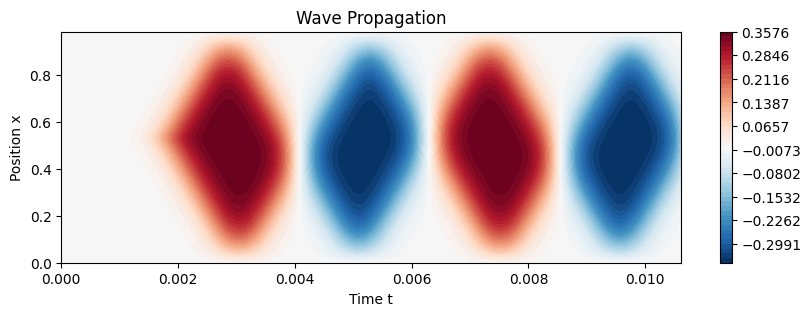

In [59]:
# Give any randomized forcing space/time function
force_x_F[None] = force_x_F_randomizer()
force_t_F[None] = force_t_F_randomizer()
force_tau[None] = force_tau_randomizer()
fdtd_simulation()

u_data = u.to_numpy()
x_coords = np.linspace(0, (nx-1) * dx, nx)
t_coords = np.linspace(0, (nt-1) * dt, nt)
T, X = np.meshgrid(t_coords, x_coords)

levels = np.linspace(u_data.min(), u_data.max(), 50)

plt.figure(figsize=(10, 3))
contour = plt.contourf(T, X, u_data, levels=levels, cmap='RdBu_r')
plt.xlabel('Time t')
plt.ylabel('Position x')
plt.title('Wave Propagation')
plt.colorbar(contour)

if False:
    import librosa, librosa.display
    from IPython.display import Audio, display
    audio = u_data[nx//2,:]
    sr = int(1/dt)
    display(Audio(audio, rate=sr))
    plt.figure(figsize=(5, 3))
    n_fft = min(len(audio) // 4, 2048)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=n_fft)), ref=np.max)
    librosa.display.specshow(D, y_axis='log', x_axis='time', sr=sr)
    plt.axhline(y=f0, color='r', linestyle='--', linewidth=2)
    plt.colorbar()
    plt.title('Spectrogram')
    plt.show()


Below is a function that simulates a ground truth by
1. Defining the GT excitation parameters
2. Computing the FDTD simulation
3. Saving the result as `target_trajectory` array.

In [60]:
def create_target_trajectory(simulated_args=None, observation_preset=None):
    """Create a target trajectory with an external force"""
    target_data = np.zeros((n_obs, nt), dtype=np.float32)
    obs_index_data = np.zeros(n_obs, dtype=np.int32)
    # Sample true force parameters
    # Assign to Taichi fields (target force parameters)
    force_x_F[None] = truth_force_x_F
    force_t_F[None] = truth_force_t_F
    force_tau[None] = truth_force_tau
    # Run simulation to generate target
    assign_ic()
    fdtd_simulation()
    u_data = u.to_numpy()
    # Choose observation points
    if observation_preset is not None:
        assert len(observation_preset) == n_obs, observation_preset
    for n in range(n_obs):
        frac = observation_preset[n] if observation_preset is not None else (0.6 * np.random.rand() + 0.2)
        obs_idx = int(frac * nx)
        obs_index_data[n] = obs_idx
        x_obs[n] = obs_idx * dx
        target_data[n, :] = u_data[obs_idx, :]
    obs_index.from_numpy(obs_index_data)
    target_trajectory.from_numpy(target_data)

Now, that's it! We implemented the FDTD simulation using a differentiable package (Taichi in this case), and gradient backpropagation will be computed automatically in the backend.

## Helper Functions

For plotting and saving results.

In [61]:
import os
import glob
import imageio
from taichi.tools.video import VideoManager
from IPython.display import clear_output

def visualize_results(is_final=False, global_minmax=None):
    """Visualize the optimization results"""
    # Run final simulation to get results
    fdtd_simulation()
    compute_loss()

    plt.close('all')
    clear_output(wait=True)
    nrows = n_obs + 1
    fig, ax = plt.subplots(nrows=nrows, ncols=2, figsize=(17, 3 * nrows))

    # Plot 1: Optimized force distribution
    x_coords = np.linspace(0, (nx-1) * dx, nx)
    # Compute Gaussian force distribution at optimized position
    pos = force_x_F[None] * max_x_F
    sigma = dx
    force_dist = np.exp(-(x_coords - pos)**2 / (2 * sigma**2))

    ax[0,0].plot(x_coords, force_dist, 'm-', linewidth=2, label='Force magnitude')
    ax[0,0].axvline(x=pos, color='k', linestyle='--', linewidth=2, label=f'Force position x={pos:.3f}')
    for n in range(n_obs):
        ax[0,0].axvline(x=x_obs[n], color='yellow', linestyle='--', linewidth=2, label='Observation point' if n==0 else None)
    ax[0,0].axvline(x=truth_force_x_F * max_x_F, color='red', linestyle=':', linewidth=2, label='Truth force position')
    ax[0,0].set_xlabel('Position x')
    ax[0,0].set_ylabel('Force magnitude')
    ax[0,0].set_title('Optimized Force Distribution')
    ax[0,0].grid(True)
    ax[0,0].legend(loc='upper right')

    # Plot 2: Wave evolution (space-time contour)
    u_data = u.to_numpy()
    t_coords = np.linspace(0, (nt-1) * dt, nt)
    T, X = np.meshgrid(t_coords, x_coords)

    levels = np.linspace(u_data.min(), u_data.max(), 50)
    contour = ax[0,1].contourf(T, X, u_data, levels=levels, cmap='RdBu_r')
    for n in range(n_obs):
        ax[0,1].axhline(y=x_obs[n], color='yellow', linestyle='--', linewidth=2, label=f'Observation point)' if n==0 else None)
    ax[0,1].axvline(x=obs_start_time * dt, color='lime', linestyle=':', alpha=0.8, label='Obs window start')
    ax[0,1].axvline(x=obs_end_time * dt, color='lime', linestyle=':', alpha=0.8, label='Obs window end')
    # True force time Gaussian (mean and std)
    truth_t = truth_force_t_F * max_t_F
    truth_s = truth_force_tau * max_tau
    ax[0,1].axvline(x=truth_t, color='red', linestyle=':', linewidth=2, label='Truth force time')
    # Draw std bar for true force time
    # bar_y_truth = y_min + 0.05 * (y_max - y_min)
    bar_y_truth = truth_force_x_F * max_x_F
    ax[0,1].plot([truth_t - truth_s, truth_t + truth_s], [bar_y_truth, bar_y_truth],
                 color='red', linewidth=4, solid_capstyle='butt', label='Truth force std')
    # Estimated force time Gaussian (mean and std)
    est_t = force_t_F[None] * max_t_F
    est_s = force_tau[None] * max_tau
    ax[0,1].axvline(x=est_t, color='purple', linestyle='--', linewidth=2, label='Est force time')
    # Draw std bar for estimated force time
    y_min, y_max = ax[0,1].get_ylim()
    bar_y_est = force_x_F[None] * max_x_F
    ax[0,1].plot([est_t - est_s, est_t + est_s], [bar_y_est, bar_y_est],
                 color='purple', linewidth=4, solid_capstyle='butt', label='Est force std')
    # Labels
    ax[0,1].set_xlabel('Time t')
    ax[0,1].set_ylabel('Position x')
    ax[0,1].set_title('Wave Propagation')
    ax[0,1].legend(loc=(1.3, 0.0))
    contour.set_clim(global_minmax)
    plt.colorbar(contour, ax=ax[0,1], label='Displacement u(x,t)')

    # Plot 3: Trajectory comparison at observation point
    obs_index_data = obs_index.to_numpy()
    for n in range(n_obs):
        simulated_trajectory = u_data[obs_index_data[n], :]
        target_traj = target_trajectory.to_numpy()[n, :]

        ax[n+1,0].plot(t_coords, target_traj, 'r-', linewidth=3, label='Target trajectory', alpha=0.8)
        ax[n+1,0].plot(t_coords, simulated_trajectory, 'b--', linewidth=2, label='Simulated trajectory')

        # Highlight observation window
        obs_window_t = t_coords[obs_start_time:obs_end_time]
        obs_window_target = target_traj[obs_start_time:obs_end_time]
        obs_window_sim = simulated_trajectory[obs_start_time:obs_end_time]

        ax[n+1,0].fill_between(obs_window_t, obs_window_target, obs_window_sim,
                         alpha=0.3, color='gray', label='Error region (obs window)')

        ax[n+1,0].set_xlabel('Time t')
        ax[n+1,0].set_ylabel('Displacement')
        ax[n+1,0].set_title(f'Trajectory Matching at x = {x_obs[n]:.2f}')
        ax[n+1,0].grid(True, alpha=0.3)
        ax[n+1,0].legend()

        # Plot 4: Error analysis
        error = simulated_trajectory - target_traj
        rmse_full = np.sqrt(np.mean(error**2))
        rmse_obs = np.sqrt(np.mean(error[obs_start_time:obs_end_time]**2))

        ylim = max(1e-3, 1.2 * np.max(np.abs(error)))
        ax[n+1,1].plot(t_coords, error, 'g-', linewidth=2, label='Error (sim - target)')
        ax[n+1,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
        ax[n+1,1].axvspan(obs_start_time * dt, obs_end_time * dt, alpha=0.2, color='yellow',
                   label='Observation window')
        ax[n+1,1].set_ylim(-ylim, ylim)
        ax[n+1,1].set_xlabel('Time t')
        ax[n+1,1].set_ylabel('Error')
        ax[n+1,1].set_title(f'Error Analysis\nFull RMSE: {rmse_full:.4f}, Obs RMSE: {rmse_obs:.4f}')
        ax[n+1,1].grid(True, alpha=0.3)
        ax[n+1,1].legend()

    plt.tight_layout()
    plt.show()

    if is_final:
        # Print summary
        print(f"\n=== Optimization Summary ===")
        print(f"Final loss: {loss[None]:.6f}")
        print(f"RMSE over full time: {rmse_full:.6f}")
        print(f"RMSE over observation window: {rmse_obs:.6f}")
        print(f"Target trajectory energy: {np.sum(target_traj**2):.4f}")

## Parameter Estimation with Gradient Backprop through Differentiable Simulation

To estimate the parameters (the IC herein) using gradient backpropagation, we first need to define the loss which we take the gradient of. Since we assume that we only have our partial observation, we define our loss as the standard MSE loss over $\texttt{t}\in\texttt{T}_\texttt{obs}$ and $\texttt{x}\in\texttt{X}_\texttt{obs}$.

To update the IC through the gradient descent, it's enough to simply subtract the ICs' gradients. Optionally, we can take the gradient clipping but it's not that critical here.

In [62]:
@ti.kernel
def compute_loss():
    """Compute loss based on trajectory matching at observation point"""
    for t in range(obs_start_time, obs_end_time):
        for n in range(n_obs):
            diff = u[obs_index[n], t] - target_trajectory[n, t]
            loss[None] += diff * diff

@ti.kernel
def apply_grad_pos():
    # Update force_x_F using its gradient
    force_x_F[None] -= learning_rate_x_F * force_x_F.grad[None]
    force_x_F[None] = ti.math.clamp(force_x_F[None], 0, 1)

@ti.kernel
def apply_grad_time():
    # Update force_t_F using its gradient
    force_t_F[None] -=  learning_rate_t_F * force_t_F.grad[None]
    force_t_F[None] = ti.math.clamp(force_t_F[None], 0, 1)

@ti.kernel
def apply_grad_std():
    # Update force_tau using its gradient
    force_tau[None] -= learning_rate_tau * force_tau.grad[None]
    force_tau[None] = ti.math.clamp(force_tau[None], 0, 1)

We mark the initial displacement and velocity as differentiable fields. Using Taichi's `ti.ad.Tape`, we record all operations in the forward FDTD pass and compute gradients of a loss function (mismatch at observation points) with respect to the forcing position (`force_x_F` $=x_F$), the forcing peak time (`force_t_F` $= t_F$), and the forcing duration (`force_tau` $=\tau$).

In [63]:
def optimize_force_position():
    """Optimize the force position using gradient descent"""
    print("Starting optimization of force position, timing, and duration...")
    for iter in range(iterations):
        loss[None] = 0.0
        with ti.ad.Tape(loss):
            fdtd_simulation()
            compute_loss()
        current_loss = loss[None]
        # print(current_loss, force_x_F.grad[None], force_t_F.grad[None], force_tau.grad[None])
        if iter % 10 == 0:
            visualize_results()
        if current_loss < 1e-6:
            print(f"Converged at iteration {iter}")
            break
        apply_grad_pos()
        apply_grad_time()
        apply_grad_std()

Now we're ready to optimize the excitation functions! Running the `optimize_force_position()` will update values of the taichi variables defined in [here](https://colab.research.google.com/drive/17252KH_y_ypOXwXLEYGmDZQk5LFTMT2B#scrollTo=Ie0Q2Oy5cnns&line=5&uniqifier=1) using the gradient descent. You can run the optimization right away, but let's just see how our target and the initial guess looks like.

=== 1D Wave Equation Inverse Design ===
Grid points: 64, Time steps: 300
dx = 0.015625, dt = 3.5511363636363635e-05, gamma = 440
CFL number: 1.000
Truth force at x = 0.657 m, t_time = 0.1, std = 0.3
Initial guess for force position: 0.885 m
Initial guess for force time (mean/std): [0.2, 0.5]
Observation point: x = [0.5]
Observation time window: t = 0.002 to 0.010
Initial loss: 2.366685


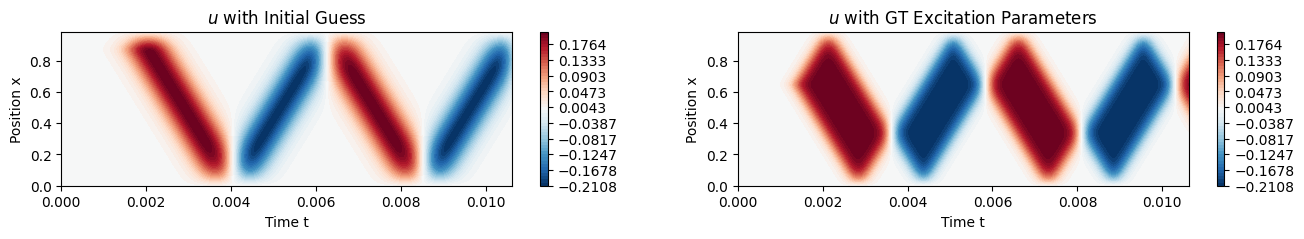

In [64]:
print("=== 1D Wave Equation Inverse Design ===")
print(f"Grid points: {nx}, Time steps: {nt}")
print(f"dx = {dx}, dt = {dt}, gamma = {gamma}")
print(f"CFL number: {gamma * dt / dx:.3f}")

# Create target trajectory
create_target_trajectory(observation_preset=np.linspace(0.1, 0.9, n_obs) if n_obs > 1 else [0.5])

# Save GT trajectory (just for visualization)
gt_data = u.to_numpy()

# Print true force parameters
print(f"Truth force at x = {truth_force_x_F:.3f} m, t_time = {truth_force_t_F:.1f}, std = {truth_force_tau:.1f}")

# Initial guess for force position and temporal Gaussian parameters
force_x_F[None] = float(force_x_F_randomizer())
force_t_F[None] = float(force_t_F_randomizer())
force_tau[None] = float(force_tau_randomizer())
print(f"Initial guess for force position: {force_x_F[None]:.3f} m")
print(f"Initial guess for force time (mean/std): [{force_t_F[None]:.1f}, {force_tau[None]:.1f}]")

print(f"Observation point: x = {x_obs}")
print(f"Observation time window: t = {obs_start_time * dt:.3f} to {obs_end_time * dt:.3f}")

# Run initial simulation to see the baseline
fdtd_simulation()
compute_loss()
print(f"Initial loss: {loss[None]:.6f}")

# Plot the initial guess along with the ground truth data
u_data = u.to_numpy()
x_coords = np.linspace(0, (nx-1) * dx, nx)
t_coords = np.linspace(0, (nt-1) * dt, nt)
T, X = np.meshgrid(t_coords, x_coords)

global_min = min(u_data.min(), gt_data.min())
global_max = max(u_data.max(), gt_data.max())
levels = np.linspace(global_min, global_max, 50)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 2))
contour1 = ax[0].contourf(T, X,  u_data, levels=levels, cmap='RdBu_r')
contour2 = ax[1].contourf(T, X, gt_data, levels=levels, cmap='RdBu_r')
for i in range(2):
  ax[i].set_xlabel('Time t')
  ax[i].set_ylabel('Position x')
ax[0].set_title('$u$ with Initial Guess')
ax[1].set_title('$u$ with GT Excitation Parameters')
plt.colorbar(contour1)
plt.colorbar(contour2)

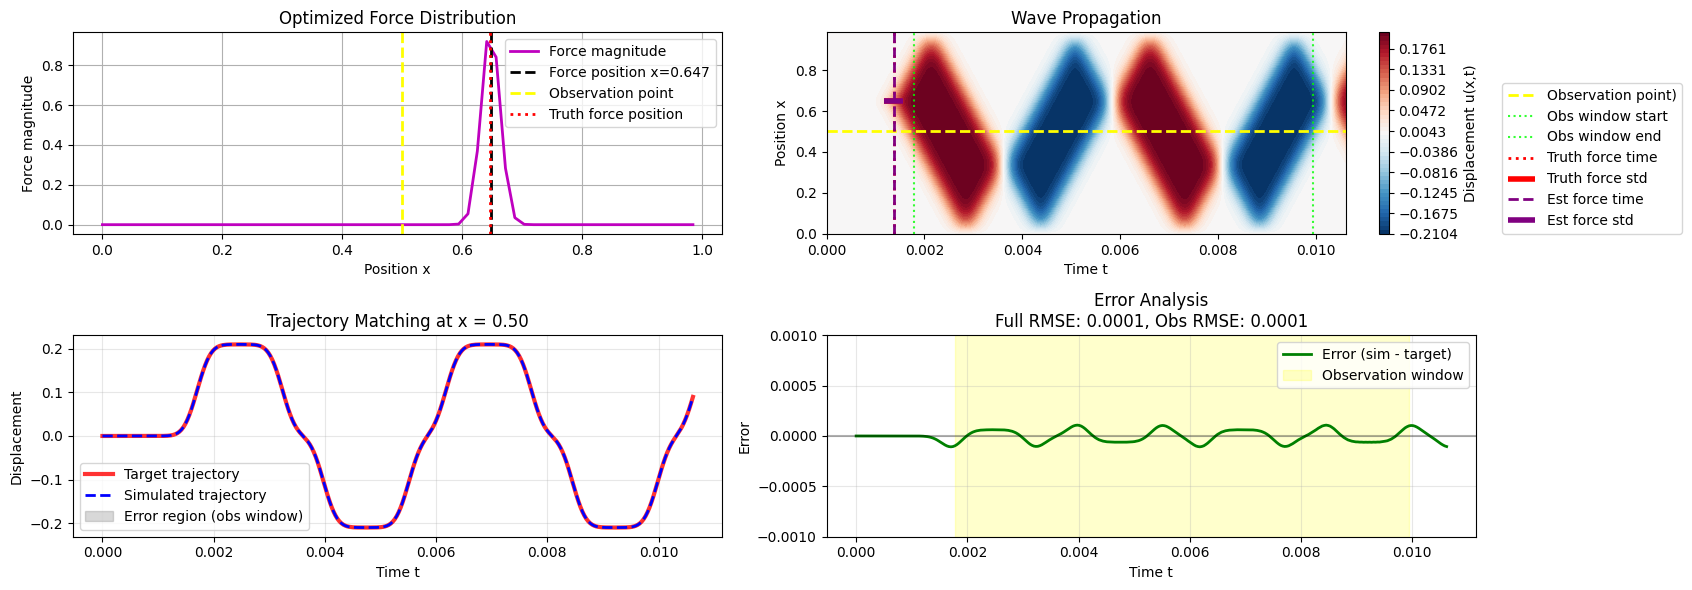


=== Optimization Summary ===
Final loss: 0.000002
RMSE over full time: 0.000059
RMSE over observation window: 0.000062
Target trajectory energy: 6.5923


In [65]:
optimize_force_position()
visualize_results(is_final=True, global_minmax=(global_min, global_max))

## Running your own simulation

You can run your own simulations with different choice of values for the variables defined [here](https://colab.research.google.com/drive/17252KH_y_ypOXwXLEYGmDZQk5LFTMT2B#scrollTo=B-_rePPbcUzv&line=7&uniqifier=1). Here are a list of variables what you might want to change:

- Observation parameters
  - `n_obs`
    - Try increasing/decreasing the number of observations.
    - More observations can result in better convergence to some extent.
  - `obs_start_time` / `obs_end_time`
    - Try adjusting the range of the observation time window.
    - Longer observation window can narrow down the solution closer to the GT.

- Optimization parameters
  - `iterations`
    - Try increasing the number of iterations.
  - `learning_rate_x_F` / `learning_rate_t_F` / `learning_rate_tau`
    - Try adjusting the learning rates.
    - Note that MSE loss decreases quadratically to the absolute error, making the gradient decrease linearly as the parameters get optimized.
      - This means that if one parameter converges fast, diminishing the error rapidly, can slow down the other parameters' convergence.
